## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [1]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

import models
import lossCalculator
import correlator
import tensorflow as tf

2025-01-09 12:17:16.424530: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-09 12:17:16.425052: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-09 12:17:16.426931: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-09 12:17:16.432264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736421436.441191   36793 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736421436.44

In [2]:
lattice_correlator = np.loadtxt('data_wilson_emconduc_48_16_b6.872.txt')
x = lattice_correlator[:,0]
mean=lattice_correlator[:,1]
error=lattice_correlator[:,2]
Jackknife_samples = lattice_correlator[:,3:].T
Nt=16
zv=.829
#add first point as last point to make it periodic
x = np.append(x, len(x))
mean = np.append(mean, mean[0])
error = np.append(error, error[0])
Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
numpoints = len(x)

In [3]:
# lattice_correlator = np.loadtxt('data_wilson_emconduc_48_16_b6.872.txt')[0:9]
# x = lattice_correlator[:,0]
# mean=lattice_correlator[:,1]
# error=lattice_correlator[:,2]
# Jackknife_samples = lattice_correlator[:,3:].T
# Nt=16

In [13]:
xr=np.arange(0, 500, 1)

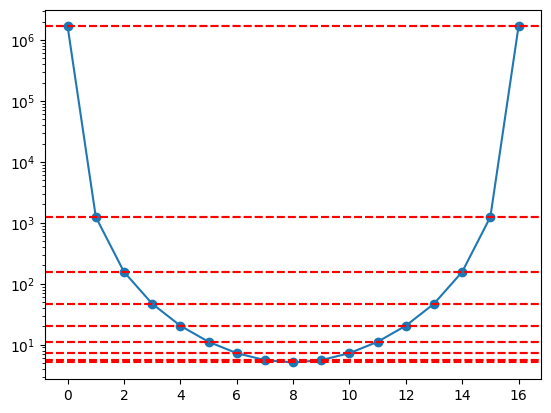

In [18]:
rhoi = tf.cast(xr, dtype=tf.float64)  # Cast rhoi to float32
# del_omega = tf.cast(del_omega, dtype=tf.float32)  # Cast delomega to float32
rhoi = tf.reshape(rhoi, [-1, 1])  # Reshape to [500, 1]

# # Perform matrix multiplication
dis = tf.matmul(klW_ker_Pos, rhoi)

plt.plot(dis, marker='o')

for y in dis:
    plt.axhline(y=y, color='r', linestyle='--')
plt.yscale('log')

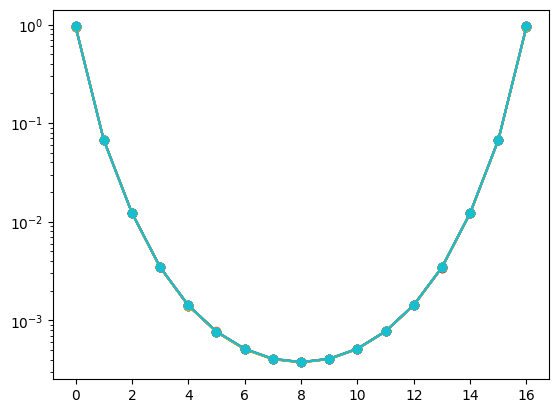

In [37]:
plt.plot(Jackknife_samples.T,marker='o')

# plt.errorbar(x, mean, yerr=error)
plt.yscale('log')

In [3]:
epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
kl_ker_Pos=correlator.KL_kernel_Position_FiniteT(x,omega,1/Nt)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))



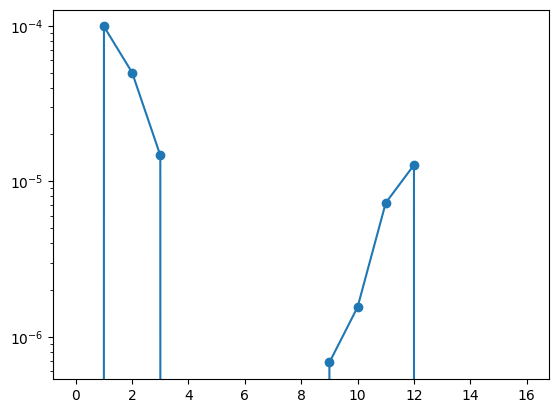

In [22]:
plt.plot(mean-mean[::-1],marker='o')
plt.yscale('log')

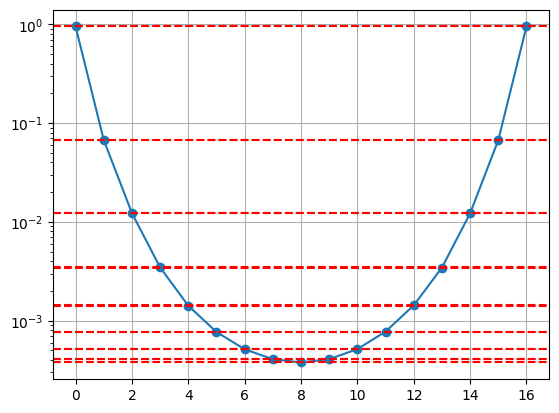

In [61]:
plt.plot(mean,marker='o')

for y in mean:
    plt.axhline(y=y, color='r', linestyle='--')
plt.yscale('log')
plt.grid()

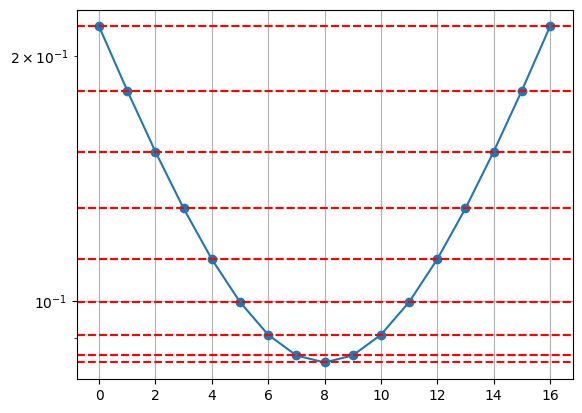

In [60]:

plt.plot(klW_ker_Pos[:,5],marker='o')

for y in klW_ker_Pos[:,5]:
    plt.axhline(y=y, color='r', linestyle='--')
plt.yscale('log')
plt.grid()

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

In [4]:
lambda_s_warmup = 1.0e-5
lambda_l2_warmup = 1.0e-5
lambda_s = 3.55323189e-05#1.0e-5#1.0e-4
lambda_l2 = 6.66754659e-08#1.0e-8
epochs=2000
new_epochs = 100000


noisy_dxi_tensor = Jackknife_samples


rho_list=[]
total_loss_history_list=[]
loss_history_list=[]



gauss_width = np.ones(len(x)) #for mean square error
# gauss_width=error
# gauss_width = mean/np.sum(mean) 
constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
kern=klW_ker_Pos


model = models.SpectralNN(num_output_nodes=len(omega), width=32, depth=3)
target_output=noisy_dxi_tensor
lossCalc=lossCalculator.LossCalculator(model=model,
                                    y_true=target_output,
                                    kernel=kern,
                                    delomega=del_omega,
                                    x=constant_input,
                                    std=gauss_width,
                                    lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                    lambda_s_func=lambda x:lambda_s,
                                    lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                    lambda_l2_func=lambda x:lambda_l2
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
trainer=models.networkTrainer(model,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history_2,loss_history_2=trainer.train(3000,warmup=False,verbose=True)

total_loss_history.extend(total_loss_history_2)
loss_history.extend(loss_history_2)

rho=model(constant_input)







2025-01-09 12:17:27.468053: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training for 2000 epochs
Epoch 0, Loss: 2248.9404296875
Epoch 200, Loss: 2.263444423675537
Epoch 400, Loss: 0.4305768311023712
Epoch 600, Loss: 0.14210844039916992
Epoch 800, Loss: 0.05762580782175064
Epoch 1000, Loss: 0.02576061710715294
Epoch 1200, Loss: 0.012112057767808437
Epoch 1400, Loss: 0.0058741383254528046
Epoch 1600, Loss: 0.002945774933323264
Epoch 1800, Loss: 0.0015718517825007439
Training took 14.076703548431396 seconds
Training for 100000 epochs
Epoch 0, Loss: 0.0009416647953912616
Epoch 10000, Loss: 6.994423983996967e-06
Epoch 20000, Loss: 5.474977569974726e-06
Epoch 30000, Loss: 4.610782525560353e-06
Epoch 40000, Loss: 4.082689429196762e-06
Epoch 50000, Loss: 3.7294262256182265e-06
Epoch 60000, Loss: 3.478431608527899e-06
Epoch 70000, Loss: 3.289587766630575e-06
Epoch 80000, Loss: 3.1425931865669554e-06
Epoch 90000, Loss: 3.019731821041205e-06
Training took 695.8147075176239 seconds
Training for 3000 epochs
Epoch 0, Loss: 2.9192510737630073e-06
Epoch 300, Loss: 2.91697

In [7]:
# np.save('data/rho_Multifit_30_corrs_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_NN',loss_history)

# np.save('data/rho_Multifit_30_corrs_rhoFit_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_rhoFit_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_rhoFit_NN',loss_history)

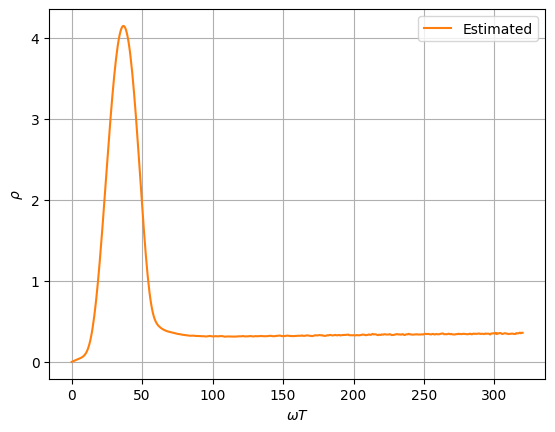

In [5]:
# singlefit result with 1 correlators
# plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega*Nt,np.squeeze(rho)*omega/Nt*Nt*3*zv**2*2*np.pi, label=r'Estimated',color='C1',marker='')
plt.legend()
# plt.xlim(0,10)
plt.xlabel(r'$\omega T$')
plt.ylabel(r'$\rho$')
plt.grid()


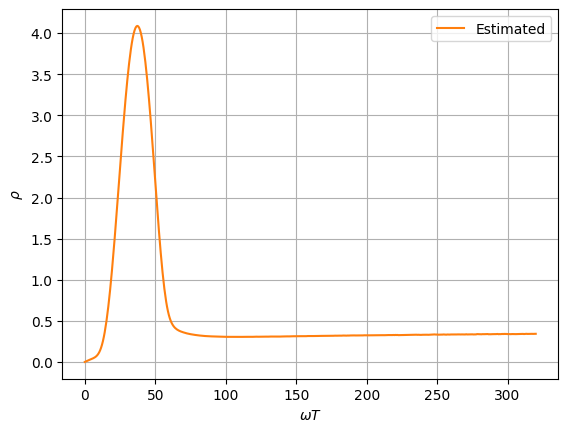

In [69]:
# singlefit result with 1 correlators
# plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega*Nt,np.squeeze(rho)*omega/Nt*Nt*3*zv**2*2*np.pi, label=r'Estimated',color='C1',marker='')
plt.legend()
# plt.xlim(0,10)
plt.xlabel(r'$\omega T$')
plt.ylabel(r'$\rho$')
plt.grid()


Text(0, 0.5, '$\\rho/\\omega$')

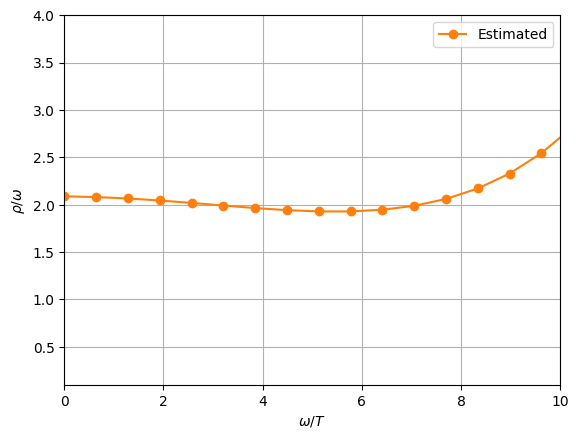

In [6]:
zv=.829
#  singlefit result with 1 correlators
# plt.plot(omega,spec2BWOmega, label=r'True')
plt.plot(omega*Nt,np.squeeze(rho)*Nt*3*zv**2*2*np.pi, label=r'Estimated',color='C1',marker='o')
plt.legend()
plt.xlim(0,10)
plt.ylim(.1,4)
plt.grid()
plt.xlabel(r'$\omega/T$')
plt.ylabel(r'$\rho/\omega$')


Text(0, 0.5, '$\\rho/\\omega$')

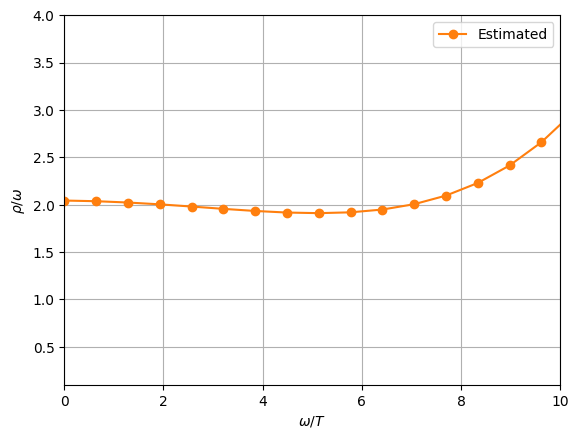

In [67]:
zv=.829
#  singlefit result with 1 correlators
# plt.plot(omega,spec2BWOmega, label=r'True')
plt.plot(omega*Nt,np.squeeze(rho)*Nt*3*zv**2*2*np.pi, label=r'Estimated',color='C1',marker='o')
plt.legend()
plt.xlim(0,10)
plt.ylim(.1,4)
plt.grid()
plt.xlabel(r'$\omega/T$')
plt.ylabel(r'$\rho/\omega$')


Text(0.5, 0, 'Epochs')

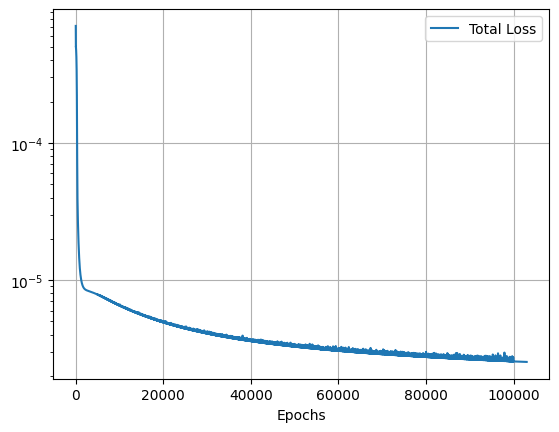

In [11]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(total_loss_history,label='Total Loss')

plt.grid()
plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

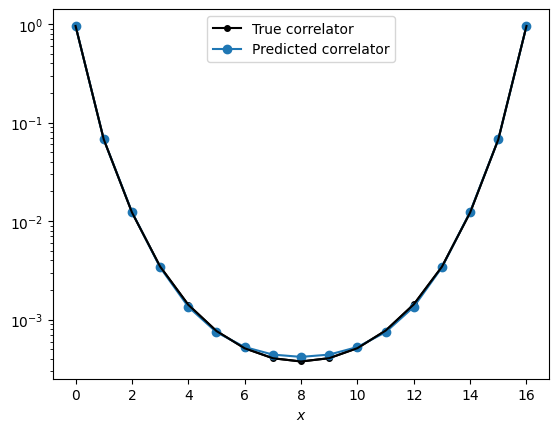

In [7]:
plt.plot(x,mean, label=r'True correlator',marker='o',color='k',ms=4)
plt.errorbar(x, mean, yerr=error, fmt='',color='k')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator

# klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)

plt.plot(x,Dxi_prediction, label=r'Predicted correlator',marker='o')
plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.show()

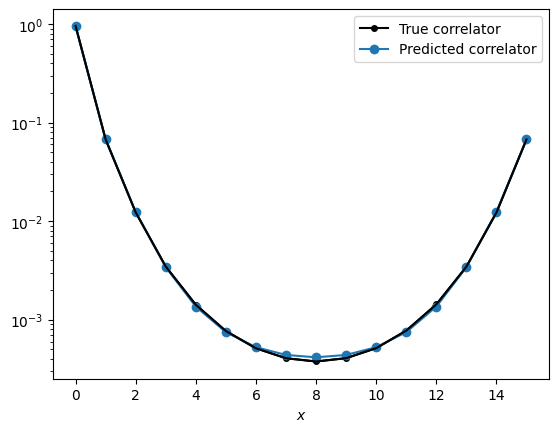

In [12]:
plt.plot(x,mean, label=r'True correlator',marker='o',color='k',ms=4)
plt.errorbar(x, mean, yerr=error, fmt='',color='k')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator

# klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)

plt.plot(x,Dxi_prediction, label=r'Predicted correlator',marker='o')
plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.show()

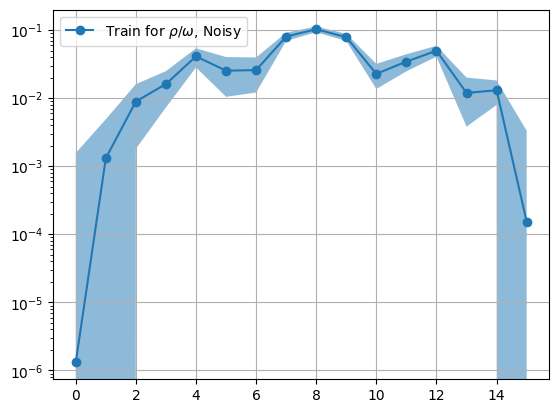

In [22]:
compareCorrelator=mean
rel_diff=np.abs(Dxi_prediction-compareCorrelator)/compareCorrelator
rel_error=error/compareCorrelator
plt.plot(x,rel_diff, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.fill_between(x,rel_diff-rel_error,rel_diff+rel_error,alpha=0.5)
# plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

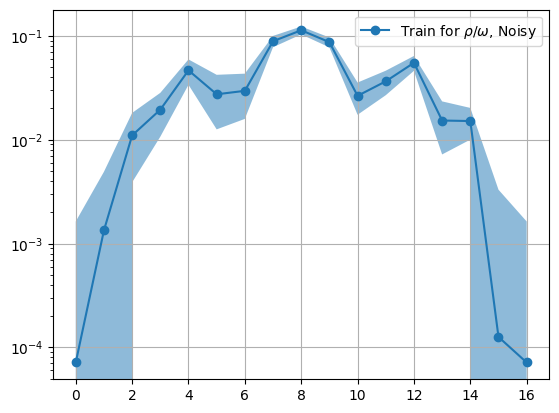

In [8]:
compareCorrelator=mean
rel_diff=np.abs(Dxi_prediction-compareCorrelator)/compareCorrelator
rel_error=error/compareCorrelator
plt.plot(x,rel_diff, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.fill_between(x,rel_diff-rel_error,rel_diff+rel_error,alpha=0.5)
# plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()